In [77]:
# import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Import machine learning and deep learning modules
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

In [78]:
# Get the current working directory
os.getcwd()

'c:\\Users\\rehan\\OneDrive\\Desktop\\Data Science\\6-Months-Data-Science\\Cloth-Recognition-Project'

In [79]:
# List all files and directories in the project path
os.listdir(r'c:\\Users\\rehan\\OneDrive\\Desktop\\Data Science\\6-Months-Data-Science\\Cloth-Recognition-Project')

['.git',
 'cloth_dataset',
 'jeans_tishart_recognization.ipynb',
 'README.md',
 'requirements.txt']

In [80]:
# Print the total number of images in the jeans dataset folder
print("Total len of jeans image : ",len(os.listdir(os.path.join('c:\\Users\\rehan\\OneDrive\\Desktop\\Data Science\\6-Months-Data-Science\\Cloth-Recognition-Project',"cloth_dataset",'jeans'))))

Total len of jeans image :  199


In [81]:
# Print the total number of images in the tshirt dataset folder
print("Total len of tshirt image : ",len(os.listdir(os.path.join('c:\\Users\\rehan\\OneDrive\\Desktop\\Data Science\\6-Months-Data-Science\\Cloth-Recognition-Project',"cloth_dataset",'tshirt'))))

Total len of tshirt image :  199


In [82]:
# Define the path to the cloth dataset directory
image_path=os.path.join(r'c:\\Users\\rehan\\OneDrive\\Desktop\\Data Science\\6-Months-Data-Science\\Cloth-Recognition-Project',"cloth_dataset")

In [83]:
# List all subdirectories or files inside the image dataset directory
os.listdir(image_path)

['jeans', 'tshirt']

In [84]:
# Initialize a dictionary to store the file paths for each category
path_dict={
    "jeans":[],
    "tshirt":[]
}
# Iterate through each category folder in the dataset directory
for key in os.listdir(image_path):
    dir_path=os.path.join(image_path,key)
    # Iterate through each image file and append its full path to the corresponding dictionary key
    for image in os.listdir(dir_path):
        path_dict[key].append(os.path.join(dir_path,image))

In [85]:
# Return the keys of the path dictionary representing the cloth categories
path_dict.keys()

dict_keys(['jeans', 'tshirt'])

In [86]:
# Import the Image module from the PIL library for image handling
from PIL import Image

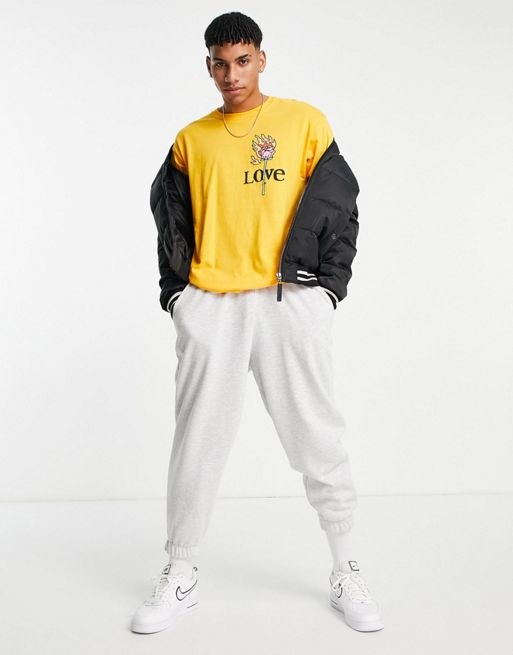

In [87]:
# Open and display a specific tshirt image using its file path
Image.open(path_dict['tshirt'][180])

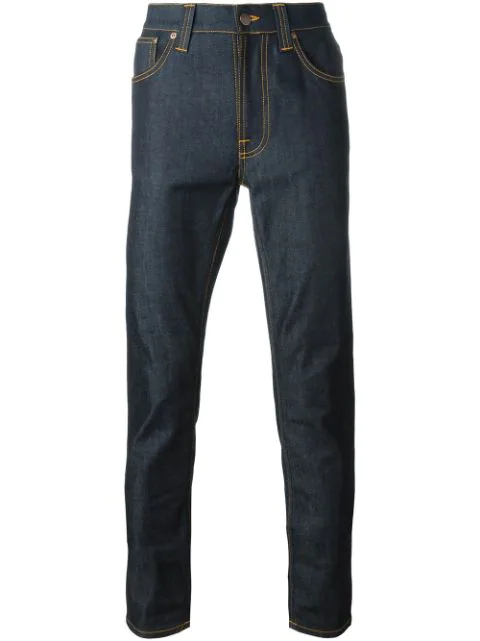

In [88]:
# Open and display a specific jeans image using its file path
Image.open(path_dict['jeans'][145])

In [89]:
# Display the dictionary containing all the image file paths categorized by clothing type

# path_dict

In [90]:
# Import OpenCV library for image and video processing
import cv2

In [91]:
# Loop through the dictionary keys and values to read, resize, and store images and their corresponding labels
y=[]
x=[]
for key , val in path_dict.items():
    for path in val:
        arr_images=cv2.imread(path)
        resized_arr_images=cv2.resize(arr_images,(223,244))
        x.append(resized_arr_images)
        y.append(key)

In [92]:
# y

In [93]:
# x

In [94]:
# Initialize LabelEncoder and convert categorical text labels into numerical values
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y= le.fit_transform(y)

In [95]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [96]:
# Convert the list of image arrays into a NumPy array for model training
x=np.array(x)

In [97]:
# Split the dataset into training and testing sets with an 80-20 ratio
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [98]:
# Normalize the training image data by dividing pixel values by 255
x_train=x_train/255
y_test=y_test/255

In [99]:
# Import the Sequential model and additional layers like Dropout for building the neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

In [100]:
# Build the Convolutional Neural Network architecture and compile it with the Adam optimizer and binary crossentropy loss
model=Sequential([
    Conv2D(128,(3,3),activation='relu',input_shape=(224,244,3)),
    MaxPool2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPool2D(2,2),
    Conv2D(32,(3,3),activation='relu'),
    MaxPool2D(2,2),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ['accuracy'])

c:\Users\rehan\OneDrive\Desktop\Data Science\boss\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
# Train the model using the training data for 20 epochs with a batch size of 32
model.fit(x_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5692 - loss: 0.8163
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7893 - loss: 0.4253
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9591 - loss: 0.1627
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9654 - loss: 0.1009
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9780 - loss: 0.0717
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9811 - loss: 0.0348
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9654 - loss: 0.0794
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9560 - loss: 0.0995
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9811 - loss: 0.0545
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9906 - loss: 0.0271
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 1.0000 - loss: 0.0081
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 1.0000 - lo